In [1]:
import pandas as pd
import os

In [ ]:
accs = ['BE_166', 'DK_229', 'DK_267']
coverage_data = []
import os
for acc in accs:
    for file in os.listdir(f'../{acc}'):
        if file.endswith('.coverage'):
            df = pd.read_table(f'../{acc}/{file}', sep='\t', header=None, names=['contig', 'position', 'coverage'])
            df = df.rename(columns={'coverage': acc})
            coverage_data.append(df)
coverage_df = pd.concat(coverage_data, axis=1)
coverage_df = coverage_df.loc[:, ~coverage_df.columns.duplicated()]

In [9]:
coverage_df.to_csv('all_coverages.csv', index=False)

In [11]:
contig = 'NC_063032.1'
min = 2673372
max = 2675809
pst425_coverage_df = coverage_df[(coverage_df['contig'] == contig) & (coverage_df['position'] >= min) & (coverage_df['position'] <= max)]

In [12]:
for column in accs:
    column_index = pst425_coverage_df.columns.get_loc(column)
    average_list = []
    for i in range(len(pst425_coverage_df)):
        if i < 5:
            rolling_av = sum(list(pst425_coverage_df.iloc[0:(i+5), column_index]))/(len(list(pst425_coverage_df.iloc[0:(i+5), column_index])))
        elif i + 5 > 2437:
            rolling_av = sum(list(pst425_coverage_df.iloc[(i-5):2437, column_index]))/(len(list(pst425_coverage_df.iloc[(i-5):2437, column_index])))
        else: rolling_av = sum(list(pst425_coverage_df.iloc[(i-5):(i+5), column_index]))/(len(list(pst425_coverage_df.iloc[(i-5):(i+5), column_index])))
        average_list.append(rolling_av)
    pst425_coverage_df[f"{column}_average"] = average_list
pst425_coverage_df.to_csv("rolling_coverage_data.csv")

/var/folders/fc/_yzh77ts62g6bd_2c_tpfty4000g63/T/ipykernel_14420/768849619.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pst425_coverage_df[f"{column}_average"] = average_list
/var/folders/fc/_yzh77ts62g6bd_2c_tpfty4000g63/T/ipykernel_14420/768849619.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pst425_coverage_df[f"{column}_average"] = average_list
/var/folders/fc/_yzh77ts62g6bd_2c_tpfty4000g63/T/ipykernel_14420/768849619.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy o

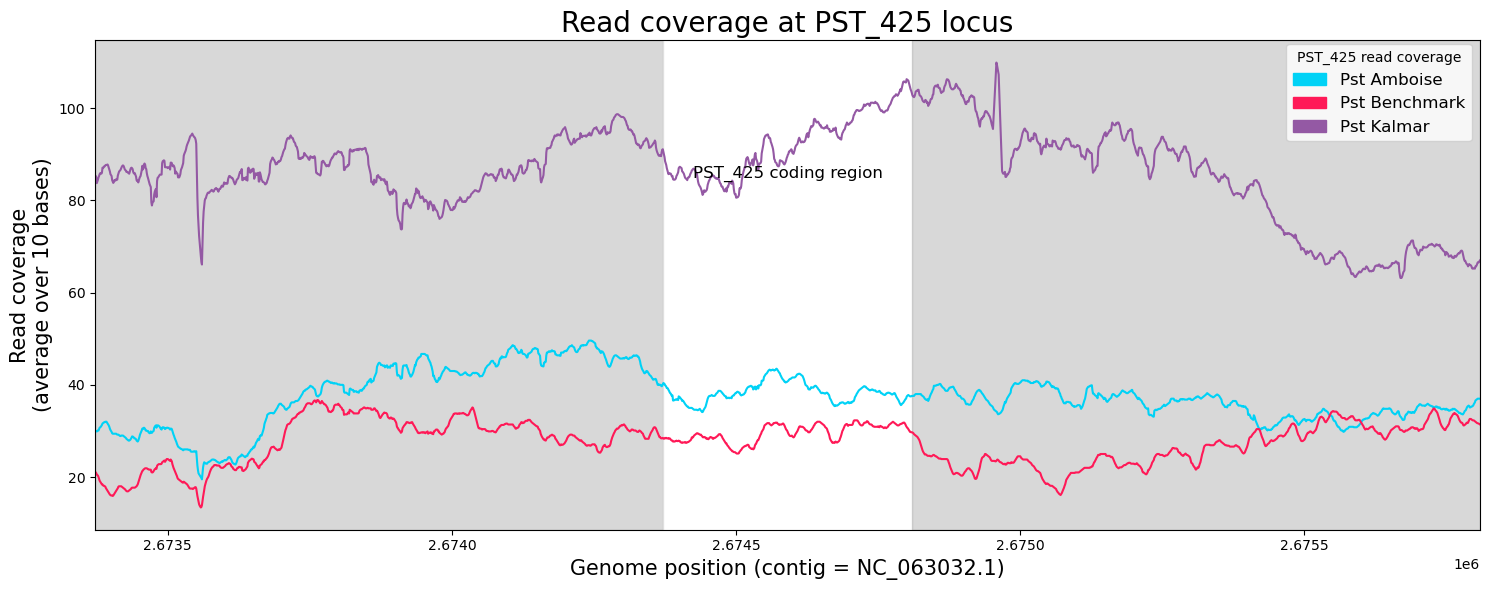

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(15, 6))
# BE166 (cv. Amboise), DK267 (cv. Kalmar) and DK229 (cv. Benchmark)
ax = sns.lineplot(data=pst425_coverage_df, x="position", y="BE_166_average", color='#00D2F6')
ax = sns.lineplot(data=pst425_coverage_df, x="position", y="DK_229_average", color='#FF1957')
ax = sns.lineplot(data=pst425_coverage_df, x="position", y="DK_267_average", color='#9459A4')
# Illustrate PST_425 coding region
ax.axvspan(2673372, 2674372, label="",color="grey", alpha=0.3)
ax.axvspan(2674372, 2674809, label="PST_425 CDS",color="white", alpha=0.3)
ax.axvspan(2674809, 2675809, label="",color="grey", alpha=0.3)

# Plot labels
ax.set_title("Read coverage at PST_425 locus",fontsize=20)
ax.set_ylabel('Read coverage\n(average over 10 bases)', fontsize=15)
ax.set_xlabel('Genome position (contig = NC_063032.1)', fontsize = 15)

# ax.annotate(('PST_425 coding region'), xy=(470, 330), xycoords='figure pixels', ha='center')
ax.annotate(('PST_425 coding region'), xy = ((2674372+((2674809 - 2674372)/2)), 85),xytext=((2674372+((2674809 - 2674372)/2)), 85),
     xycoords='data', ha='center', fontsize=12)
# Legend
BE_166_legend = mpatches.Patch(color='#00D2F6', label='Pst Amboise')
DK_229_legend = mpatches.Patch(color='#FF1957', label='Pst Benchmark')
DK_267_legend = mpatches.Patch(color='#9459A4', label='Pst Kalmar')
legend_data = [BE_166_legend, DK_229_legend, DK_267_legend]
plt.legend(handles=legend_data, title="PST_425 read coverage", fontsize=12, bbox_to_anchor=(1, 1.01))

plt.xlim(pst425_coverage_df["position"].iloc[0], pst425_coverage_df["position"].iloc[-1])
# plt.ylim(0, 100)

plt.tight_layout()
new_rc_params = {'text.usetex': False,"svg.fonttype": 'none'}
mpl.rcParams.update(new_rc_params)
plt.savefig('genome_coverage_plot_rolling_av.svg')